In [1]:
import giotto
import sklearn
from scipy.signal import spectrogram

from openml.datasets.functions import get_dataset

# Our own feature creation and plotting functions
from chaos_detection import *

In [2]:
df_res, X_betti_surfaces = create_all_features(42203, noise_level=0.0, return_betti_surface=True)

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data tranfer (pipe) to transfer data between the main process and workers.


/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases

Optimal embedding time delay based on mutual information:  5
Optimal embedding dimension based on false nearest neighbors:  14


In [13]:
fourier_window_size = 41
def get_norm(x, window_size, skip_coeffs = 1):
    if window_size%2 == 0:
        x = x[0:-1]
    r = np.linalg.norm(x[1+2*(skip_coeffs-1):].to_numpy().reshape(-1,2), ord = 2, axis = 1)
    return np.linalg.norm(r, ord = 1)
r_fft = df_res['x'].rolling(fourier_window_size).parallel_apply(
            lambda x: get_norm(x, window_size = fourier_window_size, skip_coeffs = 10),raw=False)


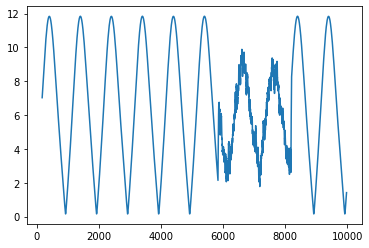

In [14]:
plt.plot(r_fft)

In [27]:
df_res.time

133      13.30133
134      13.40134
135      13.50135
136      13.60136
137      13.70137
          ...    
9978    997.89979
9979    997.99980
9980    998.09981
9981    998.19982
9982    998.29983
Name: time, Length: 9850, dtype: float64

In [44]:
nfft = 41
pad_zeros = lambda x: np.concatenate([np.zeros(int(np.ceil(nfft/2-0.5))), x, np.zeros(nfft//2)])
f, t, Sxx = spectrogram(df_res.x,
                        fs = 1, window = ('hann'),
                        nfft = nfft, nperseg = nfft,  noverlap = nfft-1)


(21,)

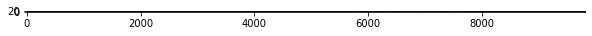

In [31]:
plt.figure(figsize = (10,8))
plt.imshow(Sxx, origin = 'lower')
f.shape

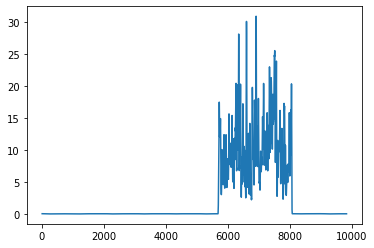

In [37]:
norms = np.linalg.norm(Sxx[0:, :], ord=1, axis=0)
plt.plot(t, norms)

In [51]:
pad_zeros(norms)[0:-1].shape

(9849,)

In [52]:
df_res['norms_spec'] = pad_zeros(norms)

In [53]:
df_res

,time,y,x,x_dot,max_10,max_20,max_50,mean_10,mean_20,mean_50,...,fourier_w_2,num_holes,avg_lifetime,betti_0,betti_1,betti_2,betti_argmax_1,betti_argmax_2,amplitude,norms_spec
133,13.30133,0,0.919056,1.520114,0.919056,0.919056,0.919056,0.895947,0.871955,0.801546,...,1.198089,100,0.011424,0.0,0.0,0.0,0,0,0.080962,0.0
134,13.40134,0,0.924506,1.521954,0.924506,0.924506,0.924506,0.900792,0.877009,0.806352,...,1.199410,100,0.011424,0.0,0.0,0.0,0,0,0.080962,0.0
135,13.50135,0,0.922732,1.517234,0.924506,0.924506,0.924506,0.904971,0.881477,0.810933,...,1.199812,100,0.011424,0.0,0.0,0.0,0,0,0.080962,0.0
136,13.60136,0,0.933383,1.522403,0.933383,0.933383,0.933383,0.910297,0.886202,0.815624,...,1.201020,100,0.011424,0.0,0.0,0.0,0,0,0.080962,0.0
137,13.70137,0,0.938219,1.523874,0.938219,0.938219,0.938219,0.915080,0.891244,0.820432,...,1.202251,100,0.011424,0.0,0.0,0.0,0,0,0.080962,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9978,997.89979,0,0.237709,1.266929,0.237709,0.237709,0.237709,0.219493,0.199745,0.141690,...,0.988467,100,0.007959,0.0,0.0,0.0,0,0,0.056302,0.0
9979,997.99980,0,0.242906,1.267638,0.242906,0.242906,0.242906,0.223579,0.203864,0.145632,...,0.989817,100,0.007959,0.0,0.0,0.0,0,0,0.056302,0.0
9980,998.09981,0,0.243808,1.269592,0.243808,0.243808,0.243808,0.227260,0.207718,0.149474,...,0.990713,100,0.007959,0.0,0.0,0.0,0,0,0.056302,0.0
9981,998.19982,0,0.249721,1.271846,0.249721,0.249721,0.249721,0.231482,0.211602,0.153327,...,0.991999,100,0.007959,0.0,0.0,0.0,0,0,0.056302,0.0


In [50]:

print(t.shape)
t

(9810,)


array([  20.5,   21.5,   22.5, ..., 9827.5, 9828.5, 9829.5])

In [27]:
df_res['time']

133      13.30133
134      13.40134
135      13.50135
136      13.60136
137      13.70137
          ...    
9978    997.89979
9979    997.99980
9980    998.09981
9981    998.19982
9982    998.29983
Name: time, Length: 9850, dtype: float64

In [5]:
import pandas as pd

In [3]:
train_f = pd.read_pickle('train_long/duffing.pickle')

In [4]:
train_f.keys()

Index(['time', 'label', 'coord_0', 'coord_1'], dtype='object')

In [5]:
train_f.head(10)

,time,label,coord_0,coord_1
0,0.00,1,0.000000,0.000000
1,0.01,1,1.018407,-0.608992
2,0.02,1,-0.451914,0.060959
3,0.03,1,-0.063318,-0.445607
4,0.04,1,-0.565119,1.000216
5,0.05,1,0.781245,-1.046075
6,0.06,1,-0.982762,0.904986
7,0.07,1,1.097820,-0.286592
8,0.08,1,0.535580,0.745841
9,0.09,1,0.090706,-0.969184


In [10]:
test_size = 0.5
noise_levels = [0.0, 0.25, 0.5, 0.75, 1.0]
for noise_l in noise_levels:
    train_f = pd.read_pickle(f'train_long/duffing_{noise_l}.pickle')
    df_r = create_non_tda_features(0,
                               rolling_max_size=[10, 20, 50],
                                 rolling_min_size=[10, 20, 50],
                                 rolling_mean_size=[10, 20, 50],
                                 fourier_coefficients=[1,2],
                                 fourier_window_size=40,
                               df = train_f)
    df_r['noise_level'] = noise_l
    df_r['test_set'] = 1*(np.random.uniform(size = (df_r.shape[0]))<test_size)
    df_r.to_pickle(f'train_long/duffing_{noise_l}spec_features.pickle')

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data tranfer (pipe) to transfer data between the main process and workers.


/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data tranfer (pipe) to transfer data between the main process and workers.


/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data tranfer (pipe) to transfer data between the main process and workers.


/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data tranfer (pipe) to transfer data between the main process and workers.


/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data tranfer (pipe) to transfer data between the main process and workers.


/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases/use_c_env/lib/python3.7/site-packages/scipy/fft/_pocketfft/helper.py:95: FutureWarning:

Series.flags is deprecated and will be removed in a future version

/Users/wojciech/Documents/use_cases

In [11]:
df_f = pd.concat([pd.read_pickle(f'train_long/duffing_{noise_l}spec_features.pickle')
                  for noise_l in noise_levels])

In [17]:
train = df_f[df_f['test_set']==0]
test = df_f[df_f['test_set']==1]
time_series = [[train[train['noise_level']==n].drop(['test_set', 'noise_level'], axis='columns'), 
               test[test['noise_level']==n].drop(['test_set', 'noise_level'], axis='columns')] 
               for n in noise_levels]

In [28]:
col_to_keep = ['time', 'y', 'max_10', 'max_20', 'max_50', 'mean_10',
                                                            'mean_20', 'mean_50', 'min_10', 'min_20', 'min_50', 
                                                            'fourier_w_1', 'fourier_w_2']
col_spec = ['time', 'y', 'spec_norm']
col_all = ['time', 'y', 'max_10', 'max_20', 'max_50', 'mean_10',
                                                            'mean_20', 'mean_50', 'min_10', 'min_20', 'min_50', 
                                                            'fourier_w_1', 'fourier_w_2', 'spec_norm']

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score
def fit_and_predict_light(f):
    result_temp = []
    for features in [col_to_keep, col_spec, col_all]:
        x_train = f[0][features].values
        y_train = f[0][['y']].values.flatten()
        x_test = f[1][features].values
        y_test = f[1][['y']].values.flatten()

        rf = GradientBoostingClassifier()
        rf.fit(x_train, y_train)
        pred = rf.predict(x_test)
        pred_df = create_pred_df(pred, y_test)
        result_temp.append(balanced_accuracy_score(pred_df['ref'], pred_df['pred']))
    return result_temp

In [ ]:
from joblib import Parallel, delayed
# Train and evaluate the datasets in parallel
results_light = Parallel(n_jobs=-1)(delayed(fit_and_predict_light)(f) for f in time_series)

In [30]:
results_light = np.array(results_light)

IndexError: index 3 is out of bounds for axis 1 with size 3

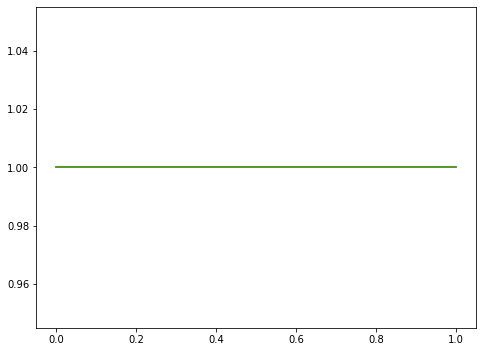

In [34]:
# Plot the results for different levels of noise and different features
np.seterr(divide='ignore') #Note: the signal to noise ratio of the non-noisy signal is inf. No warning needed here.
SNR = convert_to_SNR(time_series, np.array(noise_levels)) 
np.seterr(divide='warn') #Reactivate the warning
figure = plot_results(results_light, noise_levels, x_tick_labels=SNR, return_figure=True)
